In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import Counter

import geopandas as gpd
from shapely.geometry import Point
import geopandas as gpd

plt.rcParams["figure.figsize"] = (12, 8)

## Data Loading and Initial Inspection

In [17]:
# Load PM2.5 data
pm_file = "../data/Lucknow_LCS_images/Lucknow_PM/Lucknow_LCS_All_transformed.csv"
df_pm = pd.read_csv(pm_file)

# Display basic info
print("PM2.5 Data Shape:", df_pm.shape)
print("\nColumns:", list(df_pm.columns)[:10], "...")
print("\nFirst few rows:")
df_pm.head()

PM2.5 Data Shape: (8505, 72)

Columns: ['dt_time', 'IITK01', 'IITK02', 'IITK03', 'IITK04', 'IITK06', 'IITK07', 'IITK08', 'IITK10', 'IITK11'] ...

First few rows:


,dt_time,IITK01,IITK02,IITK03,IITK04,IITK06,IITK07,IITK08,IITK10,IITK11,...,IITK67,IITK68,IITK69,IITK70,IITK71,IITK72,IITK73,IITK74,IITK75,IITK76
0,11-Dec-2021 13:00:00,NaN,47.291433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11-Dec-2021 14:00:00,NaN,59.802787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11-Dec-2021 15:00:00,NaN,45.334969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11-Dec-2021 16:00:00,NaN,50.944956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11-Dec-2021 17:00:00,NaN,70.821570,97.781481,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Convert datetime column
df_pm["dt_time"] = pd.to_datetime(df_pm["dt_time"], format="%d-%b-%Y %H:%M:%S")
# Display data info
print("Date range:", df_pm["dt_time"].min(), "to", df_pm["dt_time"].max())
print("Total records:", len(df_pm))
print("\nData types:")
df_pm.dtypes.head(10)

Date range: 2021-12-11 13:00:00 to 2022-11-30 23:00:00
Total records: 8505

Data types:


dt_time    datetime64[ns]
IITK01            float64
IITK02            float64
IITK03            float64
IITK04            float64
IITK06            float64
IITK07            float64
IITK08            float64
IITK10            float64
IITK11            float64
dtype: object

In [ ]:
# Get sensor columns
sensor_columns = [col for col in df_pm.columns if col.startswith("IITK")]
print(f"Number of sensors: {len(sensor_columns)}")

# Flatten all PM2.5 values and remove NaN
all_pm_values = df_pm[sensor_columns].values.flatten()
all_pm_values = all_pm_values[~np.isnan(all_pm_values)]

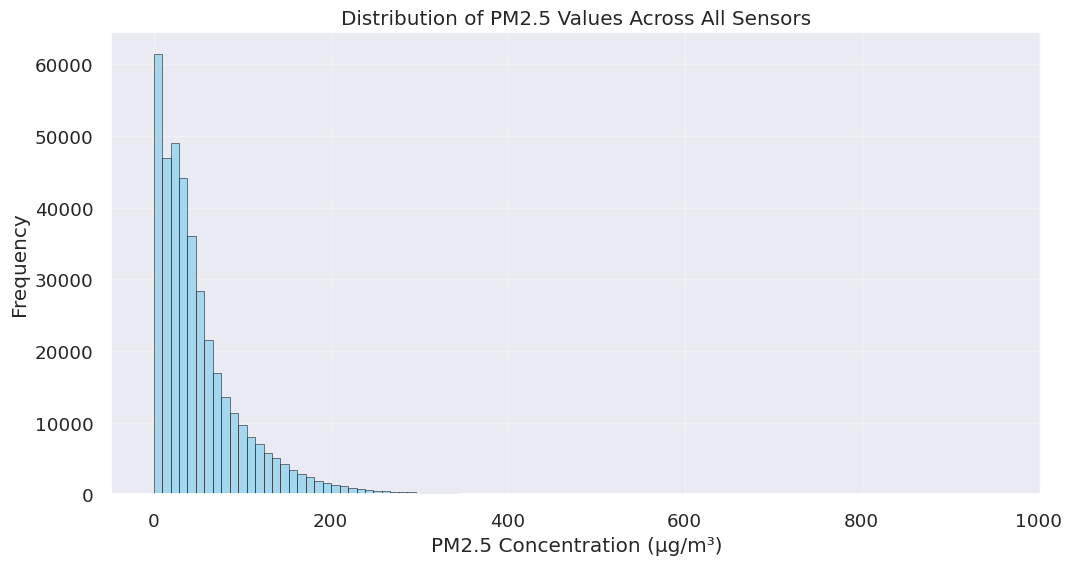

In [20]:
# Distribution of PM2.5 values
plt.figure(figsize=(12, 6))
plt.hist(
    all_pm_values,
    bins=100,
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
    linewidth=0.5,
)
plt.xlabel("PM2.5 Concentration (μg/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Values Across All Sensors")
plt.grid(True, alpha=0.3)
plt.show()

## Temporal Analysis

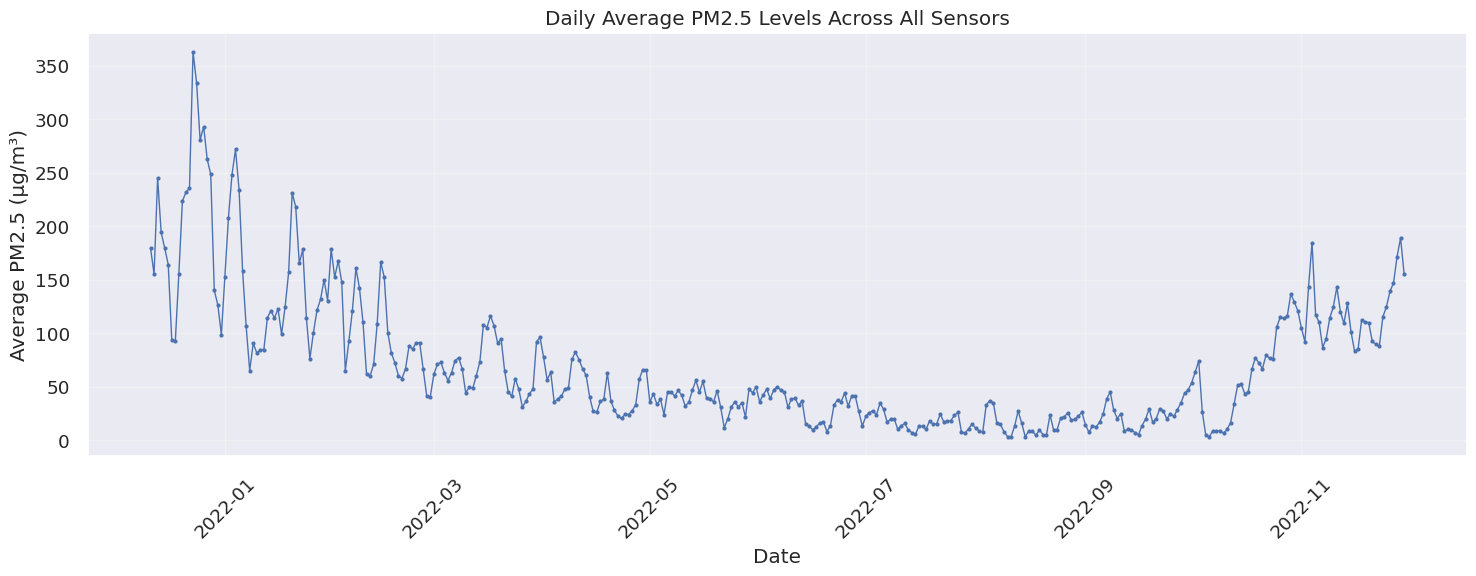

In [21]:
# Calculate average PM2.5 per day
daily_avg = df_pm.groupby(df_pm["dt_time"].dt.date)[sensor_columns].mean().mean(axis=1)

# Plot daily averages
plt.figure(figsize=(15, 6))
plt.plot(daily_avg.index, daily_avg.values, marker="o", markersize=3, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.title("Daily Average PM2.5 Levels Across All Sensors")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

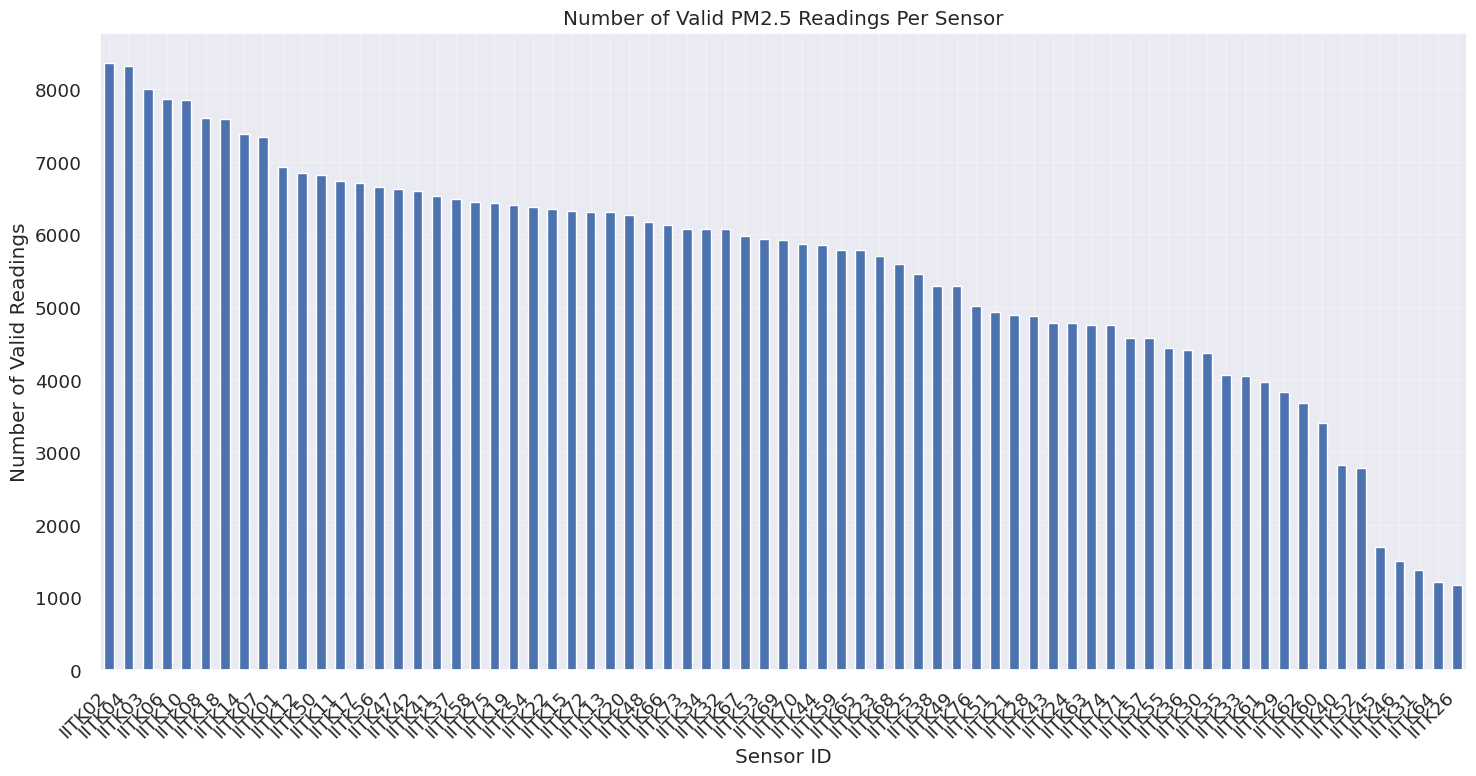

Top 5 sensors with most readings:
IITK02    8363
IITK04    8322
IITK03    8009
IITK06    7862
IITK10    7852
dtype: int64

Bottom 5 sensors with least readings:
IITK45    1690
IITK46    1506
IITK31    1374
IITK64    1218
IITK26    1171
dtype: int64


In [22]:
# Analyze readings per sensor
readings_per_sensor = df_pm[sensor_columns].count().sort_values(ascending=False)
plt.figure(figsize=(15, 8))
readings_per_sensor.plot(kind="bar")
plt.xlabel("Sensor ID")
plt.ylabel("Number of Valid Readings")
plt.title("Number of Valid PM2.5 Readings Per Sensor")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 sensors with most readings:")
print(readings_per_sensor.head())
print("\nBottom 5 sensors with least readings:")
print(readings_per_sensor.tail())

## Spatial Analysis - Sensor Locations

In [23]:
# Load sensor coordinates
coords_file = (
    "../data/Lucknow_LCS_images/Lucknow_PM/Coordinates of the sensors location.xlsx"
)
df_coords = pd.read_excel(coords_file)

print("Sensor coordinates shape:", df_coords.shape)
df_coords.head()

Sensor coordinates shape: (71, 3)


,LKO_Site,Latitude,Longitude
0,IITK01,26.779170,80.885063
1,IITK02,26.915201,80.942171
2,IITK03,26.865388,80.954702
3,IITK04,26.901733,80.951876
4,IITK06,26.904335,80.765377


In [24]:
# Merge coordinates with average PM2.5 values
# Calculate average PM2.5 for each sensor
avg_pm_per_sensor = df_pm[sensor_columns].mean().reset_index()
avg_pm_per_sensor.columns = ["Sensor", "Avg_PM2.5"]

# Merge with coordinates
df_spatial = pd.merge(
    avg_pm_per_sensor, df_coords, left_on="Sensor", right_on="LKO_Site"
)

print("Spatial data shape:", df_spatial.shape)
df_spatial.head()

Spatial data shape: (71, 5)


,Sensor,Avg_PM2.5,LKO_Site,Latitude,Longitude
0,IITK01,55.650698,IITK01,26.779170,80.885063
1,IITK02,59.177031,IITK02,26.915201,80.942171
2,IITK03,70.329341,IITK03,26.865388,80.954702
3,IITK04,62.530022,IITK04,26.901733,80.951876
4,IITK06,49.798831,IITK06,26.904335,80.765377


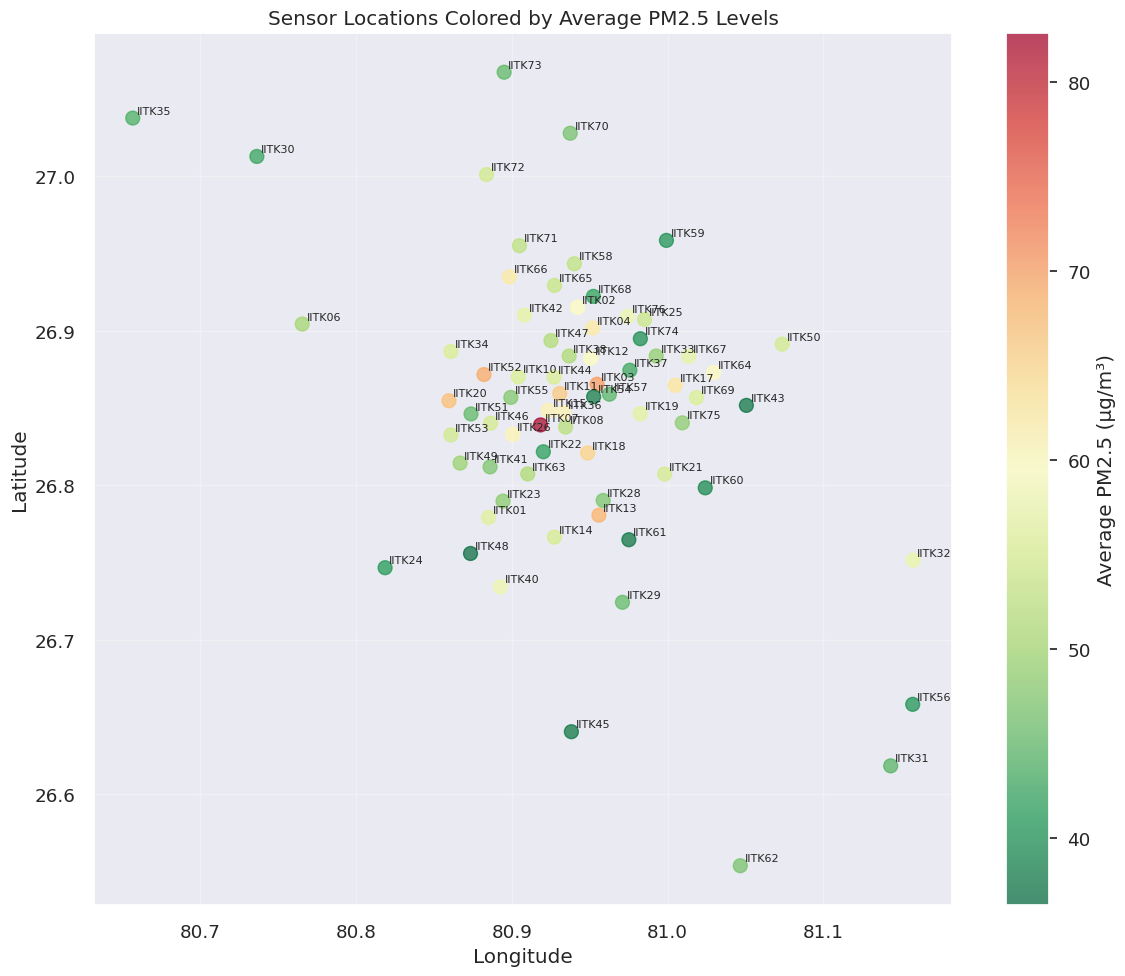

In [25]:
# Create scatter plot of sensor locations colored by average PM2.5
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df_spatial["Longitude"],
    df_spatial["Latitude"],
    c=df_spatial["Avg_PM2.5"],
    cmap="RdYlGn_r",
    s=100,
    alpha=0.7,
)
plt.colorbar(scatter, label="Average PM2.5 (μg/m³)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sensor Locations Colored by Average PM2.5 Levels")
plt.grid(True, alpha=0.3)

# Add sensor labels
for i, row in df_spatial.iterrows():
    plt.annotate(
        row["Sensor"],
        (row["Longitude"], row["Latitude"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## Satellite Image Analysis

In [26]:
# Analyze satellite image filenames
image_dir = "../data/Lucknow_LCS_images/Sat_Images/"
image_files = os.listdir(image_dir)

print(f"Total satellite images: {len(image_files)}")
print("\nSample image filenames:")
for img in image_files[:5]:
    print(img)

Total satellite images: 13616

Sample image filenames:
00000_Transport_Nagar_2021-12-25_04-49-09_1039.png
00001_Transport_Nagar_2021-12-27_04-22-51_22.png
00002_Transport_Nagar_2021-12-27_05-47-36_71.png
00003_Transport_Nagar_2021-12-27_05-47-38_71.png
00004_Transport_Nagar_2021-12-27_07-38-42_0f02.png


In [ ]:
# Extract date information from filenames
# Extract dates
dates = []
locations = []

for filename in image_files:
    # Extract date (YYYY-MM-DD format)
    date_match = re.search(r"(\d{4}-\d{2}-\d{2})", filename)
    if date_match:
        dates.append(date_match.group(1))

    # Extract location (text between second underscore and date)
    parts = filename.split("_")
    if len(parts) >= 3:
        locations.append(parts[1])

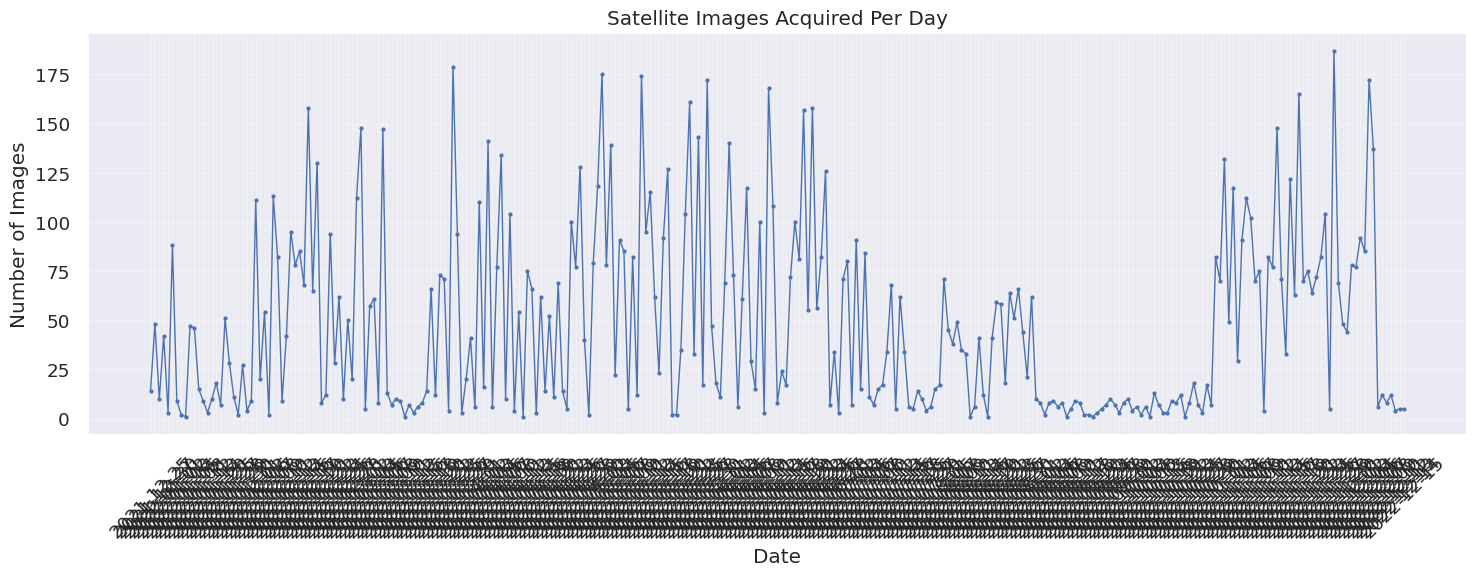

In [28]:
# Plot image count by date
date_counts = Counter(dates)
sorted_dates = sorted(date_counts.keys())
counts = [date_counts[date] for date in sorted_dates]

plt.figure(figsize=(15, 6))
plt.plot(sorted_dates, counts, marker="o", markersize=3, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Number of Images")
plt.title("Satellite Images Acquired Per Day")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Integration Strategy

In [29]:
# Analyze temporal overlap between PM data and satellite images
pm_dates = pd.to_datetime(df_pm["dt_time"]).dt.date.unique()
satellite_dates = pd.to_datetime(list(set(dates))).date

print(f"PM data date range: {min(pm_dates)} to {max(pm_dates)}")
print(f"Satellite image date range: {min(satellite_dates)} to{max(satellite_dates)}")

# Find overlapping dates
overlap_dates = set(pm_dates) & set(satellite_dates)
print(f"\nOverlapping dates: {len(overlap_dates)} days")
print(f"Percentage of PM data covered:{len(overlap_dates) / len(pm_dates) * 100:.1f}%")

PM data date range: 2021-12-11 to 2022-11-30
Satellite image date range: 2021-12-25 to2022-12-15

Overlapping dates: 272 days
Percentage of PM data covered:76.6%
